## Notebook 5: Photometric Redshift Estimation Under Real Survey Biases

**Audience:** First-year PhD students in Astrophysics  
**Theme:** Regression with incomplete information and selection effects

---

### Astrophysics context

Spectroscopic redshifts measure galaxy distances precisely by identifying spectral lines and fitting their wavelength shift.

However, spectroscopy is expensive in telescope time, so only a fraction of survey galaxies receive spectroscopic labels.

Imaging surveys instead observe galaxies through a small number of broad filters (u, g, r, i, z, ...). From these fluxes or colours we estimate:

> photometric redshift, often called **photo-z**

This is one of the most important machine-learning tasks in observational cosmology and survey astronomy.

---

### Scientific question

> Given noisy colours and magnitudes, what redshift is most likely?

Unlike textbook regression problems, the mapping is imperfect because:

- different galaxy spectra can yield similar colours
- noise erases information
- catastrophic photometric failures occur
- spectroscopic training labels are biased toward bright objects

---

### What you will learn

- Colour-redshift physics (4000 Å break)
- Selection-function bias
- Linear vs nonlinear regressors
- Catastrophic outliers
- Standard photo-z metrics
- Approximate predictive PDFs P(z)
- Performance vs magnitude and redshift
- Why information limits matter

---

### Core idea

Machine learning can approximate:

> colours → redshift but cannot recover information absent from the observables.


## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import PartialDependenceDisplay

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split


# Set Random Seed and Plotting Style

This step initializes reproducibility and configures the default visualization settings.

A fixed random seed is defined to ensure that any random processes (such as sampling or model initialization) produce consistent results across runs. A NumPy random generator is created using this seed.

The plotting style is also set to a predefined Matplotlib theme that improves readability and accessibility. Default figure size and font size are adjusted to make all plots clearer and more consistent throughout the notebook.

These settings ensure that results are both reproducible and visually consistent across all visualizations.

In [2]:
SEED = 42
np.random.seed(SEED)

plt.style.use("tableau-colorblind10")
plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["font.size"] = 12


# Simulated Galaxy Catalogue with Colour Evolution

We construct a synthetic galaxy catalogue to mimic how real astronomical surveys observe galaxies across cosmic time. 

The goal is to simulate how galaxy colours evolve with redshift, including realistic observational noise and measurement failures.

## Generate synthetic galaxy sample

We simulate a catalogue of 8000 galaxies. 

Each galaxy is assigned a true redshift randomly distributed between 0 and 2.0. This represents the underlying cosmological population we aim to study.


In [3]:
N = 10000

# True spectroscopic redshift
z_spec = np.random.uniform(0, 2.0, N)

## Physical motivation: the 4000 Å break

A key feature in galaxy spectra is the **4000 Å break**, a sharp drop in flux caused by absorption in older stellar populations.

As redshift increases:
- the spectrum shifts toward redder wavelengths,
- the 4000 Å break moves through optical filters (u, g, r, i, z),
- galaxy colours change in a redshift-dependent way.

To model this effect, we use a smooth transition function (logistic function), which approximates how spectral features gradually move through filter bands.


In [4]:
def logistic(x, x0, w):
    """
    Smooth step function.
    
    Used here to mimic a spectral break entering a filter pair.
    x0 = central redshift where transition occurs
    w  = width of transition
    """
    return 1 / (1 + np.exp(-(x - x0) / w))


## Apparent magnitude evolution

We define a baseline apparent magnitude in the i-band that increases with redshift. This encodes the physical fact that more distant galaxies appear fainter due to cosmological dimming and distance effects.


In [5]:
i_true_old = 19.0 + 1.25 * np.log1p(z_spec)
# 1. Intrinsic Scatter (Mean -21 is standard for an L* galaxy)
# 1. Broaden the intrinsic scatter (The "Challenge" term)
# 1.25 to 1.5 is the sweet spot. It's larger than the distance signal, 
# preventing the model from using brightness as a proxy for distance.
M_intrinsic = np.random.normal(-21.0, 1.25, size=N)

# 2. Strengthen the Distance Modulus (The "Physics" term)
# In astronomy, distance modulus is proportional to 5 * log10(d).
# We use a simplified proxy for cosmological dimming rather than a full ΛCDM luminosity distance.
distance_modulus = 5.0 * np.log10(z_spec + 1)

# 3. The Anchor (The "Scale" term)
# 38.5 keeps your i_true mean around 19-20 mag (matching your old scale).
i_true = M_intrinsic + distance_modulus + 38.5

# 4. Evolution (The "Expert" term)
# Keep this! It simulates physical changes in galaxies over time.
i_true += 0.5 * np.log1p(z_spec)

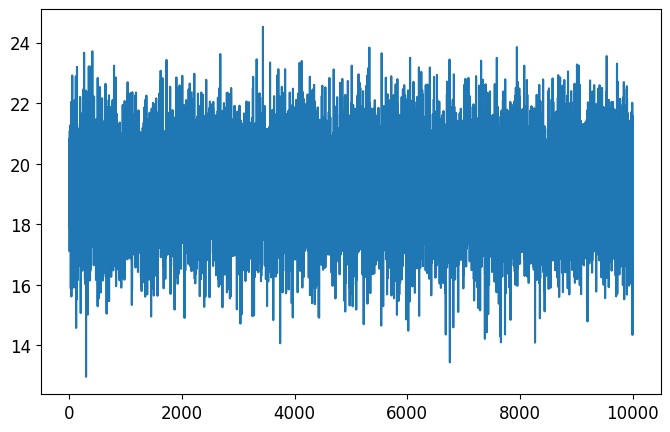

In [6]:
plt.plot(i_true_old, color="tab:red")
plt.plot(i_true, color="tab:blue")

## Colour evolution with redshift

Galaxy colours evolve because spectral features shift across photometric filters as redshift increases.

We model this by defining smooth redshift-dependent transitions for standard colour indices (u−g, g−r, r−i, i−z). Each transition corresponds to the 4000 Å break moving from one filter band to the next.


In [7]:
u_g_true = 1.0 + 1.4 * logistic(z_spec, 0.35, 0.05)
g_r_true = 0.7 + 1.1 * logistic(z_spec, 0.75, 0.07)
r_i_true = 0.5 + 0.9 * logistic(z_spec, 1.15, 0.08)
i_z_true = 0.3 + 0.8 * logistic(z_spec, 1.55, 0.10)
u_g_true += np.random.normal(0, 0.1, N)
g_r_true += np.random.normal(0, 0.1, N)
population_type = np.random.choice([0,1], size=N)
# shift colours differently
u_g_true += population_type * 0.5
g_r_true += population_type * 0.3

## Constructing true magnitudes

From the baseline magnitude and colour relations, we reconstruct consistent magnitudes in all filters. This ensures that the synthetic photometry is internally physically consistent, meaning all colours correspond to a plausible spectral energy distribution.


In [8]:
# Anchor band (faintness evolution)
i_mag_true = i_true

# Work backwards / forwards through colours
r_mag_true = i_mag_true + r_i_true
g_mag_true = r_mag_true + g_r_true
u_mag_true = g_mag_true + u_g_true

# z band goes redder from i
z_mag_true = i_mag_true - i_z_true

## Observational noise

Real astronomical data are always noisy, and faint galaxies are measured with larger uncertainty.

We model this using a noise level that increases with magnitude. This produces heteroscedastic errors, meaning the uncertainty depends on object brightness, as in real telescope observations.

We then apply Gaussian noise to each photometric band to simulate measurement errors.


In [9]:
#sigma = 0.02 + 0.025 * (i_mag_true - 19.0)**2
sigma = np.clip(0.02 + 0.025 * (i_mag_true - 19.0)**2, None, 0.3)

u = u_mag_true + np.random.normal(0, sigma)
g = g_mag_true + np.random.normal(0, sigma)
r = r_mag_true + np.random.normal(0, sigma)
i = i_mag_true + np.random.normal(0, sigma)
zmag = z_mag_true + np.random.normal(0, sigma)


## Catastrophic measurement failures

In real surveys, a small fraction of sources are severely corrupted due to issues such as blending, deblending failures, or instrumental artefacts.

We simulate this by randomly selecting a small subset of galaxies and injecting large additional noise into their measurements. These outliers represent catastrophic failures in the measurement pipeline.


In [10]:
idx = np.random.choice(np.arange(N), size=int(0.03 * N), replace=False)

u[idx] += np.random.normal(0, 1.0, len(idx))
g[idx] += np.random.normal(0, 0.9, len(idx))
r[idx] += np.random.normal(0, 0.9, len(idx))


## Build final dataset

Finally, we assemble all simulated quantities into a structured dataset containing:
- photometric magnitudes in all bands,
- measurement uncertainties,
- and the true redshift of each galaxy.


In [11]:
df = pd.DataFrame({
    "u": u,
    "g": g,
    "r": r,
    "i": i,
    "zmag": zmag,
    "sigma": sigma,
    "z_spec": z_spec
})


## Derived colours

We compute colour indices by taking differences between magnitudes in adjacent filters. These colour combinations are often more informative than raw magnitudes because they directly trace the shape of the galaxy spectrum.


In [12]:
df["u_g"] = df["u"] - df["g"]
df["g_r"] = df["g"] - df["r"]
df["r_i"] = df["r"] - df["i"]
df["i_z"] = df["i"] - df["zmag"]

df = df.reset_index(drop=True)

df.head()


,u,g,r,i,zmag,sigma,z_spec,u_g,g_r,r_i,i_z
0,22.236055,19.389965,17.688667,17.251600,16.749401,0.107071,0.749080,2.846090,1.701297,0.437067,0.502199
1,24.481564,22.158470,20.345040,18.937856,17.910336,0.020092,1.901429,2.323093,1.813430,1.407184,1.027520
2,23.747085,23.534471,22.903713,20.371241,19.812838,0.068658,1.463988,0.212614,0.630758,2.532472,0.558403
3,21.492546,21.901880,19.212965,18.202660,17.788758,0.038674,1.197317,-0.409334,2.688915,1.010306,0.413902
4,22.295950,20.814910,20.109173,19.638513,19.287251,0.029496,0.312037,1.481040,0.705737,0.470660,0.351262


## Scientific meaning

This synthetic dataset encodes:
- cosmological redshift evolution,
- movement of the 4000 Å spectral break,
- realistic photometric noise,
- and rare catastrophic measurement errors.

It is designed to mimic real survey data and can be used to test methods for **photometric redshift estimation from galaxy colours**.

# Colour–Redshift Relation

This plot visualizes one of the key relationships that photometric redshift models rely on: the connection between galaxy colour and redshift.

In particular, we examine how the **g − r colour evolves with redshift**, which is strongly influenced by the 4000 Å spectral break.

---

## Physical interpretation: colour transition

The underlying model produces a smooth but rapid transition in colour as redshift increases.

- At **low redshift**, the g − r colour remains relatively constant and low (bluer galaxies).
- Around a specific redshift (~0.75), the colour increases sharply.
- At **higher redshift**, the colour stabilizes again at a higher (redder) value.

This transition reflects the **4000 Å break shifting from the g band into the r band**, altering the observed flux in these filters.

---

## Effect of observational noise

The scatter in the plot is not uniform:

- At **low redshift**, the points are tightly clustered.
- At **high redshift**, the distribution becomes much broader.

This is due to **heteroscedastic noise**, where measurement uncertainty increases for fainter (more distant) galaxies. As a result, the underlying physical trend becomes harder to detect at high redshift.

---

## Presence of outliers

A small fraction of points lie far from the main trend.

These correspond to **catastrophic measurement failures**, introduced to mimic real observational issues such as:
- blended sources,
- incorrect photometric measurements,
- detector artefacts.

These outliers can significantly affect simple models and motivate the use of more robust machine learning methods.

---

## What this means for machine learning

This plot illustrates the core challenge:

- There is a **clear physical signal** (colour–redshift relation),
- but it is degraded by **noise and outliers**.

A successful model must therefore:
- capture non-linear relationships,
- handle increasing uncertainty with redshift,
- remain robust to anomalous data points.

The transition region reflects the simulated 4000 Å break entering different filters.


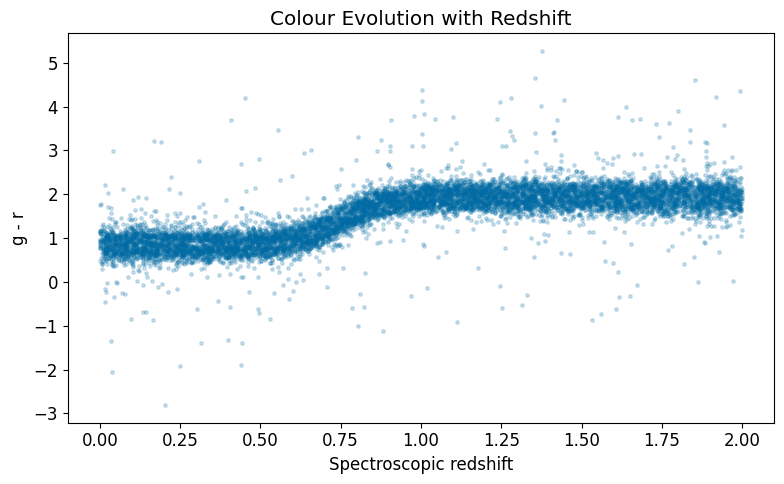

In [13]:
plt.scatter(df["z_spec"], df["g_r"], s=6, alpha=0.2)
plt.xlabel("Spectroscopic redshift")
plt.ylabel("g - r")
plt.title("Colour Evolution with Redshift")
plt.tight_layout()
plt.show()


# Training-Set Bias (Selection Function)

In real astronomical surveys, obtaining spectroscopic redshifts is expensive and time-consuming. As a result, **only a subset of galaxies—typically the brightest ones—receive reliable labels**.

This creates a fundamental problem: the **training set is not representative of the full galaxy population** observed in imaging surveys.

---

## Feature representation

We consider two different ways to describe each galaxy:

- **Colours only**: combinations such as (u−g, g−r, r−i, i−z), which trace the *shape of the spectrum*.
- **Colours + magnitudes**: adds apparent brightness information (e.g. r and i bands).

Colours are generally more robust across different surveys, while magnitudes depend strongly on observational depth.

---

## The selection function (source of bias)

The training sample is constructed by selecting only **bright galaxies**.

This mimics a real observational constraint:
- faint galaxies require long exposure times to obtain spectroscopic redshifts,
- therefore they are underrepresented (or completely absent) in labeled datasets.

This brightness cut defines the **selection function**, which introduces a systematic bias.

---

## Train/test split and domain shift

Instead of a random split, we create a **physically motivated separation**:

- **Training set**: only bright galaxies  
- **Test set**: the full population, including faint galaxies  

This creates a **domain shift**:
- the model is trained on one distribution (bright objects),
- but evaluated on a broader and different distribution (including faint objects).

---

## Bright vs faint populations

The dataset naturally separates into:

- **Bright galaxies**: well-measured, included in training  
- **Faint galaxies**: noisier, excluded from training but present at test time  

This mismatch is a key challenge in real-world applications.

---

## Why this is problematic

The model may implicitly learn shortcuts such as:

- associating brightness with redshift (e.g. “bright = nearby”),
- instead of learning the true physical relationship between colour and redshift.

When applied to faint galaxies:
- the model encounters data it has never seen before,
- predictions can become unreliable or biased.

This is a classic example of **out-of-distribution (OOD) generalization**.

---

## Scientific implication

This setup reproduces one of the central difficulties in photometric redshift estimation:

- labeled data are **biased and incomplete**,  
- while predictions are required for the **full, unbiased survey population**.

Handling this mismatch is essential for building robust and physically meaningful models.

In [14]:
features_full = ["u_g", "g_r", "r_i", "i_z", "r", "i"]
features_col = ["u_g", "g_r", "r_i", "i_z"]

X = df[features_full]
y = df["z_spec"]

#train_mask = df["r"] < 21.0
# This mimics real surveys where targeting probability decreases smoothly with magnitude, 
# rather than a hard cutoff.
prob = 1 / (1 + np.exp((df["r"] - 21)))
train_mask = np.random.rand(N) < prob

X_train_val = X.loc[train_mask]
y_train_val = y.loc[train_mask]

# Evaluate on full survey distribution
X_test = X.copy()
y_test = y.copy()

#bright_mask = df["r"] < 21.0
#faint_mask = df["r"] >= 21.0

X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=SEED)


threshold        = X_train_val["r"].max()
bright_mask_val  = X_val["r"] <= threshold
faint_mask_val   = X_val["r"] > threshold

bright_mask_test = X_test["r"] <= threshold
faint_mask_test  = X_test["r"] > threshold

print("Training   size: ", len(X_train))
print("Validation size: ", len(X_val))
print("Test size:       ", len(X_test))

print("Validation Bright objects:", bright_mask_val.sum())
print("Validation Faint  objects:", faint_mask_val.sum())

print("Test Bright objects:", bright_mask_test.sum())
print("Test Faint  objects:", faint_mask_test.sum())


Training   size:  5114
Validation size:  1279
Test size:        10000
Validation Bright objects: 1279
Validation Faint  objects: 0
Test Bright objects: 9950
Test Faint  objects: 50


# Visualizing Selection Bias

This plot highlights one of the most critical issues in the dataset: **selection bias in the training sample**. It shows how the distribution of galaxies used for training differs from the full survey population.

---

## Full survey population

The first histogram represents all galaxies in the dataset.

- It typically peaks at **fainter magnitudes**.
- This reflects a fundamental property of the universe:  
  there are **many more faint galaxies than bright ones**.

This distribution represents the **true population** we ultimately want to model.

---

## Spectroscopic training sample

The second histogram shows only the galaxies used for training.

- It includes **only bright objects**.
- It stops sharply at a limiting magnitude (r = 21).

This subset corresponds to galaxies for which spectroscopic redshifts are available.

---

## The missing population

To the right of the magnitude limit lies a large number of galaxies that:

- are present in the survey,
- but **do not have labels**,
- and are therefore excluded from training.

This creates a gap between:
- what the model **learns from** (bright galaxies),
- and what it is **asked to predict on** (the full population).

---

## Consequence: covariate shift

This mismatch leads to **covariate shift**, where the distribution of input features differs between training and testing.

In practice, this means:

- the model learns relationships valid for bright galaxies,
- but must generalize to fainter galaxies it has never seen.

---

## Why this is a problem

A model trained on this biased sample may:

- implicitly associate brightness with redshift,
- fail when encountering faint galaxies with similar redshifts,
- produce overly optimistic performance during training,
- but degrade significantly on real survey data.

---

## Scientific implication

This plot exposes a fundamental limitation of supervised learning in astronomy:

- labeled data are **not representative** of the full population,
- and careful methods are required to account for this bias.

Understanding and correcting for this effect is essential for reliable photometric redshift estimation.

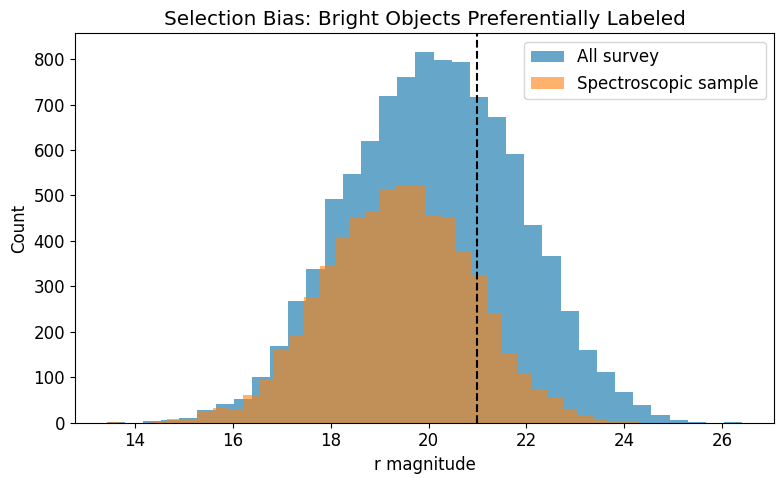

In [15]:
plt.hist(df["r"], bins=35, alpha=0.6, label="All survey")
plt.hist(df.loc[train_mask, "r"], bins=35, alpha=0.6, label="Spectroscopic sample")
plt.axvline(21.0, ls="--", color="black")
plt.xlabel("r magnitude")
plt.ylabel("Count")
plt.title("Selection Bias: Bright Objects Preferentially Labeled")
plt.legend()
plt.tight_layout()
plt.show()


# Models

In this section, we compare three different machine learning approaches to estimate galaxy redshift from photometric data. The goal is to understand how well each model learns the underlying physical relation and, more importantly, how well it generalizes beyond the biased training sample.

---

## Models under comparison

We consider three models with increasing complexity:

- **Linear Regression**: a simple baseline model  
- **Random Forest**: a nonlinear ensemble of decision trees  
- **Gradient Boosting**: a sequential ensemble optimized for high accuracy  

---

## Linear Regression: baseline model

This model assumes a simple linear relationship between input features (colours and magnitudes) and redshift.

- It tries to fit redshift as a weighted combination of the inputs.
- It is easy to interpret and fast to train.

However:
- it cannot capture nonlinear patterns,
- it struggles with the smooth transitions produced by the 4000 Å break,
- it tends to average over sharp changes in the data.

---

## Random Forest: robust nonlinear model

Random Forest builds many independent decision trees and averages their predictions.

- It naturally captures nonlinear relationships.
- It is robust to noise and outliers.
- It handles irregular patterns in the data well.

Because predictions are averaged across many trees, the model is less sensitive to catastrophic measurement errors.

---

## Gradient Boosting: high-precision model

Gradient Boosting builds trees sequentially:

- each new tree focuses on correcting the errors of the previous ones,
- the model gradually improves its predictions.

This approach:
- captures subtle and complex patterns,
- often achieves very high accuracy,
- can model the detailed structure of the colour–redshift relation.

However, it can be more sensitive to noise and overfitting if not carefully tuned.

---

## Training strategy

All models are trained on the **biased training sample** (bright galaxies only), but evaluated on the **full survey**.

This setup reflects a realistic scenario:
- training data are incomplete and biased,
- predictions are required for the entire population.

---

## Evaluation metrics

Model performance is evaluated using the **Root Mean Square Error (RMSE)** under three conditions:

- **RMSE (All)**: performance on the full dataset  
- **RMSE (Bright)**: performance on galaxies similar to the training sample  
- **RMSE (Faint)**: performance on galaxies not seen during training  

---

## Interpreting the results

The key comparison is between **Bright** and **Faint** performance:

- If a model performs well on bright galaxies but poorly on faint ones, it indicates **poor generalization**.
- This typically means the model has learned patterns specific to the training sample rather than the true underlying physics.

A large gap between these two metrics is a clear sign of **selection bias effects**.

---

## Scientific takeaway

This experiment illustrates a central challenge in photometric redshift estimation:

- models can achieve excellent performance on biased training data,
- but fail when applied to the full survey population.

Even advanced models cannot fully overcome this limitation without addressing the underlying bias in the training set.

In [ ]:
# Tree-based models do not require feature scaling.
models = {
    "Linear Regression":
        Pipeline([
            ("scale", StandardScaler()),
            ("model", LinearRegression())
        ]),
    
    "Random Forest":
        RandomForestRegressor(
            n_estimators=300,
            random_state=SEED,
            n_jobs=-1
        ),
    
    "Gradient Boosting":
        GradientBoostingRegressor(
            n_estimators=250,
            learning_rate=0.05,
            max_depth=3,
            random_state=SEED
        )
}

predictions_val = {}

predictions_test = {}

rows = []

for name, model in models.items():
    
    # Train only on biased bright sample
    model.fit(X_train, y_train)
    pred_val = model.predict(X_val)
    predictions_val[name] = pred_val
    rmse_all_val = np.sqrt(mean_squared_error(y_val, pred_val))
    rmse_bright_val = np.sqrt(mean_squared_error(y_val[bright_mask_val], pred_val[bright_mask_val]))
    
    # Predict entire survey
    pred_test = model.predict(X_test)
    predictions_test[name] = pred_test
    
    rmse_all_test = np.sqrt(mean_squared_error(y_test, pred_test))
    rmse_bright_test = np.sqrt(mean_squared_error(y_test[bright_mask_test], pred_test[bright_mask_test]))
    rmse_faint_test = np.sqrt(mean_squared_error(y_test[faint_mask_test], pred_test[faint_mask_test]))
    
    rows.append([name, rmse_all_val, rmse_bright_val, 
                 rmse_all_test, rmse_bright_test, rmse_faint_test])

results = pd.DataFrame(
    rows,
    columns=["Model", "RMSE All Val",  "RMSE Bright Val",  
                      "RMSE All Test", "RMSE Bright Test", "RMSE Faint Test"]
)

results


# Photo-z Performance Metrics

In this section, we evaluate the quality of photometric redshift (photo-z) predictions using standard metrics from observational cosmology.

Different metrics capture different aspects of model performance, including systematic errors, typical scatter, and the presence of catastrophic failures.

---

## Why normalized errors?

In astronomy, prediction errors are typically normalized by (1 + z).

This is because:
- redshift stretches spectral features,
- the same absolute error has different physical meaning at low and high redshift.

By normalizing, we compare errors on a consistent, physically meaningful scale across the full redshift range.

---

## Metrics used

### Bias

Bias measures the **average offset** between predicted and true redshift.

- A bias close to zero indicates no systematic shift.
- A positive or negative bias indicates that the model consistently overestimates or underestimates redshift.

---

### RMSE (Root Mean Square Error)

RMSE measures the overall prediction error:

- sensitive to large deviations,
- strongly affected by outliers.

It provides a global measure of performance but can be misleading if a small number of predictions are very wrong.

---

### NMAD (Normalized Median Absolute Deviation)

NMAD is a **robust measure of scatter**:

- based on the median instead of the mean,
- much less sensitive to extreme outliers.

It reflects how well the model performs for the majority of galaxies.

---

### Catastrophic outlier fraction

This metric measures the fraction of galaxies with large normalized errors.

- these are cases where the predicted redshift is significantly wrong,
- even if most predictions are accurate.

Such failures are particularly important in astronomy, where even a small fraction of bad estimates can bias scientific results.

---

## Interpreting the metrics

Each metric highlights a different aspect of model behavior:

- **Low bias** → no systematic offset  
- **Low NMAD** → tight predictions for most galaxies  
- **Low RMSE** → few large errors  
- **Low outlier fraction** → rare catastrophic failures  

Comparing RMSE and NMAD is especially informative:

- if RMSE is much larger than NMAD → errors are dominated by a few extreme outliers  
- if both are large → the model is broadly inaccurate  

---

## Scientific takeaway

A good photometric redshift model is not just accurate on average, but also:

- unbiased,
- robust to noise,
- and resistant to catastrophic failures.

These metrics together provide a comprehensive view of model performance in realistic astronomical conditions.

In [ ]:
best = "Gradient Boosting"
pred = predictions_test[best]

# Standard normalized residual
dz = (pred - y_test) / (1 + y_test)

bias = np.median(dz)
rmse = np.sqrt(mean_squared_error(y_test, pred))
nmad = 1.48 * np.median(np.abs(dz - np.median(dz)))
rmse_norm = np.sqrt(np.mean(dz**2))

outlier_frac = np.mean(np.abs(dz) > 0.15)

print("Best model:", best)
print("Bias            :", round(bias, 5))
print("RMSE            :", round(rmse, 5))
print("NMAD            :", round(nmad, 5))
print("RMSE Normalized :", round(rmse_norm, 5))
print("Outlier fraction:", round(outlier_frac, 5))


# Predicted vs True Redshift

This plot compares the **true redshift** with the **predicted redshift** using a hexagonal binning visualization (hexplot).

Unlike a standard scatter plot, this representation groups points into hexagonal cells and encodes their density, making it easier to interpret large datasets.

---

## Why a hexplot?

With thousands of galaxies, a scatter plot becomes overcrowded and difficult to read.

A hexplot solves this by:
- grouping nearby points into bins,
- showing how many objects fall into each region,
- highlighting the underlying structure of the data.

Darker regions indicate higher density of galaxies.

---

## The ideal case

In a perfect model:

- all points would lie along the **diagonal line (y = x)**,
- this would appear as a thin, high-density ridge,
- indicating perfect agreement between predicted and true redshift.

The **thickness** of this diagonal reflects the typical prediction error (scatter).

---

## Scatter around the diagonal

The spread of points around the diagonal shows how precise the model is:

- narrow distribution → high precision  
- wide distribution → larger uncertainty  

This spread is directly related to the model’s ability to recover the true redshift.

---

## Behaviour at high redshift

At higher redshift values, a common pattern may appear:

- predictions tend to cluster below the true values,
- forming a horizontal structure in the plot.

This indicates that the model is **underestimating high-redshift galaxies**.

The cause is typically **selection bias**:
- the model was trained mostly on lower-redshift (brighter) galaxies,
- it struggles to extrapolate beyond that range.

---

## Catastrophic outliers

Some regions may show isolated clusters far from the diagonal.

These represent **catastrophic failures**, where predictions are significantly incorrect.

In astronomy, this often arises from **degeneracy**:
- different redshift galaxies can have similar observed colours,
- making them difficult to distinguish using photometry alone.

---

## Density patterns

The darkest regions indicate where most galaxies lie.

- if these regions align well with the diagonal → good overall performance  
- if they are systematically offset → the model has a **global bias**  

---

## Scientific interpretation

This visualization provides a compact summary of model behavior:

- accuracy (alignment with diagonal),  
- precision (scatter around it),  
- bias (systematic offsets),  
- and failure modes (outliers and degeneracies).  

It is one of the most informative diagnostic tools for photometric redshift estimation.

In [ ]:
# Perfect predictions would lie on the diagonal.

g = sns.jointplot(x=y_test, y=pred, kind="hex", height=7)
g.fig.suptitle("True vs Predicted Redshift", y=1.02)
plt.show()


# Residual Structure

This plot shows the **residuals** of the model, defined as the difference between predicted and true redshift, as a function of the true redshift.

Rather than focusing on correct predictions, this visualization highlights **where and how the model makes mistakes**, making it a powerful diagnostic tool.

---

## Why residuals matter

By plotting prediction error against true redshift, we can identify:

- systematic biases,
- changes in uncertainty,
- and regions where the model consistently fails.

A well-behaved model should produce residuals that are randomly scattered around zero, with no visible structure.

---

## Reference line: zero error

The horizontal line at zero represents perfect predictions.

- points above the line → the model **overestimates** redshift  
- points below the line → the model **underestimates** redshift  

If the model were perfect, all points would lie exactly along this line.

---

## Systematic bias (tilt)

A common pattern is a **tilted distribution**:

- at **low redshift**, residuals tend to be positive (overestimation),
- at **high redshift**, residuals tend to be negative (underestimation).

This indicates a systematic effect where the model is biased toward intermediate values.

This behavior is often caused by **regression to the mean**:
- the model has seen mostly moderate redshift values during training,
- and tends to pull predictions toward that range.

---

## Increasing scatter (heteroscedasticity)

The vertical spread of residuals often increases with redshift:

- low redshift → tight distribution (small errors)  
- high redshift → wide distribution (large errors)  

This reflects the fact that:
- distant galaxies are fainter,
- their measurements are noisier,
- and predictions become more uncertain.

---

## Structured patterns

If the residuals show visible patterns such as waves or clusters, this indicates that the model is not fully capturing the underlying physics.

These structures can arise from:
- ambiguities in the colour–redshift relation,
- transitions associated with the 4000 Å break,
- or degeneracies where different redshifts produce similar observed colours.

---

## Scientific interpretation

A good model should produce residuals that are:

- centered around zero (unbiased),
- randomly distributed (no structure),
- and with controlled scatter.

Any systematic trend or pattern in this plot reveals limitations in the model or in the training data, and provides guidance for improving the analysis.

In [ ]:
g = sns.jointplot(
    x=y_test,
    y=pred - y_test,
    kind="scatter",
    s=8,
    alpha=0.15,
    height=7
)

g.ax_joint.axhline(0, color="red", ls="--")

#plt.axhline(0, color="red", ls="--")
plt.suptitle("Residuals vs Redshift", y=1.02)
plt.show()


# Performance vs Redshift

This plot shows how the model’s prediction error changes as a function of redshift. Instead of summarizing performance with a single number, we examine how accuracy evolves across different distance ranges.

---

## Why this matters

In astronomy, model performance is rarely uniform across redshift:

- nearby galaxies are easier to measure and predict,
- distant galaxies are fainter and noisier,
- training data are often biased toward low redshift.

This plot helps identify **where the model is reliable** and where it begins to fail.

---

## Method overview

The redshift range is divided into several bins covering the full interval from 0 to 2.

For each bin:
- we select galaxies within that redshift range,
- compute the prediction error (RMSE) for that subset,
- and only include bins with sufficient data to ensure statistical reliability.

The result is a curve showing how error varies with redshift.

---

## Typical behavior

### Low redshift

At low redshift:
- errors are generally small and stable,
- galaxies are brighter and better measured,
- spectral features are clearly captured in the photometric bands.

---

### Intermediate redshift

At intermediate redshift, the error may increase or show localized peaks.

These features often arise from:
- **transition regions**, where spectral features move between filters,
- **degeneracies**, where different galaxy types produce similar colours.

---

### High redshift

At high redshift:
- errors typically increase significantly,
- predictions become less reliable.

This is due to two main effects:

- **Selection bias**: the model has seen few high-redshift examples during training  
- **Measurement noise**: distant galaxies are faint, leading to noisier inputs  

---

## Scientific interpretation

This plot defines the **effective range of validity** of the model.

It allows us to identify:
- redshift ranges where predictions are trustworthy,
- regions where caution is required,
- and where additional data or improved modeling may be needed.

---

## Practical implication

In real applications, this type of analysis is essential.

It informs decisions such as:
- restricting scientific analyses to reliable redshift ranges,
- weighting data by uncertainty,
- or improving the training set to better cover underrepresented regions.

In [ ]:
bins = np.linspace(0, 2, 9)
centers = 0.5 * (bins[:-1] + bins[1:])

vals = []

for i_bin in range(len(bins)-1):
    
    if i_bin == len(bins) - 2:
        m = (y_test >= bins[i_bin]) & (y_test <= bins[i_bin+1])
    else:
        m = (y_test >= bins[i_bin]) & (y_test < bins[i_bin+1])
    
    if m.sum() > 30:
        vals.append(np.sqrt(mean_squared_error(y_test[m], pred[m])))
    else:
        vals.append(np.nan)

plt.plot(centers, vals, marker="o")
plt.xlabel("Redshift")
plt.ylabel("RMSE")
plt.title("Error vs Redshift")
plt.tight_layout()
plt.show()


# Performance vs Magnitude

This plot examines how model performance changes as a function of **apparent brightness** (r-band magnitude). While redshift-based diagnostics probe distance dependence, this analysis directly connects model accuracy to **data quality**.

---

## Why magnitude matters

In observational astronomy:

- brighter galaxies → higher signal-to-noise ratio  
- fainter galaxies → noisier measurements  

Since machine learning models rely on photometric inputs, their performance is strongly affected by measurement uncertainty. This makes magnitude one of the most important variables for assessing reliability.

---

## Method overview

The full range of r-band magnitudes is divided into several bins.

For each bin:
- galaxies within that brightness range are selected,
- the prediction error (RMSE) is computed,
- only bins with sufficient data are retained to ensure stability.

This produces a curve showing how error varies with brightness.

---

## Typical behavior

### Bright regime

At low magnitudes (bright galaxies):

- errors are small and stable,  
- measurements are precise,  
- spectral features are clearly captured.  

In this regime, the model operates under optimal conditions.

---

### Transition region

As magnitude increases, a transition occurs:

- noise in the photometry increases,  
- colour measurements become less reliable,  
- model performance begins to degrade.  

This region often marks the boundary between well-measured and noisy data.

---

### Faint regime

At high magnitudes (faint galaxies):

- errors increase rapidly,  
- predictions become significantly less reliable.  

This is driven by two combined effects:

- **measurement noise**: faint galaxies have low signal-to-noise ratios  
- **training bias**: the model has not seen many faint examples during training  

---

## Connection to selection bias

A key feature to look for is a sharp increase in error near the magnitude limit used to define the training set.

This reflects a transition from:
- **in-distribution data** (bright galaxies seen during training),  
to  
- **out-of-distribution data** (faint galaxies unseen during training).  

---

## Scientific interpretation

This plot defines the **limiting magnitude** of the analysis:

- below a certain brightness → predictions are reliable  
- beyond that threshold → errors grow quickly and confidence decreases  

---

## Practical implication

In real surveys, this type of analysis is essential for:

- determining which galaxies can be safely used in scientific studies,  
- setting magnitude cuts for reliable samples,  
- understanding how observational limitations affect results.  

---

## Key takeaway

Average performance metrics can be misleading.

A model may perform very well on bright galaxies but poorly on faint ones. This plot makes that contrast explicit, revealing how model reliability depends strongly on data quality.

In [ ]:
# Fainter galaxies are noisier, so prediction quality degrades.
#mag_bins = np.linspace(df["r"].min(), df["r"].max(), 8)
#mag_bins = np.quantile(X_test["r"], np.linspace(0,1,8))
mag_bins = np.unique(np.quantile(X_test["r"], np.linspace(0,1,8)))

mag_cent = 0.5 * (mag_bins[:-1] + mag_bins[1:])

vals = []

for i_bin in range(len(mag_bins)-1):
    
    m = (X_test["r"] >= mag_bins[i_bin]) & (X_test["r"] < mag_bins[i_bin+1])
    
    if m.sum() > 30:
        vals.append(np.sqrt(mean_squared_error(y_test[m], pred[m])))
    else:
        vals.append(np.nan)

plt.plot(mag_cent, vals, marker="o")
plt.xlabel("r magnitude")
plt.ylabel("RMSE")
plt.title("Error vs Magnitude")
plt.tight_layout()
plt.show()


# Performance Split: Domain Shift Check

This section provides a direct diagnostic of **domain shift**, by comparing model performance on two physically distinct subsets of the data: bright galaxies (similar to the training set) and faint galaxies (not represented in training).

This is one of the most important checks in any realistic photometric redshift pipeline.

---

## The two regimes

We evaluate model performance separately in two regions of the survey:

### Bright regime

This subset contains galaxies with:

- high signal-to-noise photometry,
- similar properties to the spectroscopic training set,
- reliable measurements.

This represents **in-distribution performance**, meaning the model is evaluated on data similar to what it was trained on.

---

### Faint regime

This subset contains galaxies with:

- low brightness,
- higher photometric noise,
- no representation in the training set.

This represents **out-of-distribution performance**, and is the true test of model generalization.

---

## The generalization gap

The key quantity of interest is the difference between:

- error on bright galaxies,
- error on faint galaxies.

In realistic scenarios, the faint regime almost always shows significantly higher error.

This difference is known as the **generalization gap under domain shift**.

---

## Why faint galaxies are harder

### 1. Instrumental noise

Faint galaxies suffer from lower signal-to-noise ratio:

- photon counts are lower,
- measurement uncertainty is higher,
- colours become less precise.

This directly increases prediction uncertainty.

---

### 2. Training set bias

The model has been trained primarily on bright galaxies.

As a result:

- it learns relationships valid only in that regime,
- it has limited exposure to faint objects,
- and it struggles to extrapolate beyond the training distribution.

This is a classic case of **selection bias leading to distribution mismatch**.

---

## Scientific interpretation

This comparison reveals a critical limitation:

> performance on the training-like subset does not reflect performance on the full survey.

In practice, this means:

- standard validation scores can be overly optimistic,
- real survey performance is often significantly worse,
- faint galaxies dominate the error budget in cosmological analyses.

---

## Practical implication

To improve results, astronomers often:

- reweight training samples to better match the full population,
- collect additional spectroscopic data for faint galaxies,
- or use models that explicitly account for domain shift.

---

## Key takeaway

A model is not truly reliable unless it performs well on **both regimes**.

The gap between bright and faint performance is one of the clearest indicators of how well a model will behave in real observational conditions.

In [ ]:
rmse_bright = np.sqrt(mean_squared_error(y_test[bright_mask_test], pred[bright_mask_test]))
rmse_faint = np.sqrt(mean_squared_error(y_test[faint_mask_test], pred[faint_mask_test]))

print("RMSE bright regime:", rmse_bright)
print("RMSE faint regime :", rmse_faint)


This is the key lesson:

> low error on labeled bright galaxies does not guarantee low error on the full survey.


## Feature importance

This code generates a **Feature Importance Plot**, which reveals the "internal logic" of your Gradient Boosting model.

It tells you which specific pieces of information—colors or raw magnitudes—the model relied on most to make its redshift predictions.

Notice that feature importance reflects predictive utility, not causal physics!

### 1. What the code is doing

The `feature_importances_` attribute in Gradient Boosting calculates how much each feature contributed to reducing the error (impurity) across all the trees in the ensemble. 
* A **high value** means the model frequently used that feature to make critical "decisions."
* A **low value** means the feature was either noisy or redundant.

### 2. How to interpret the results

In this notebook, you are using `features_full`, which includes both **colors** (`u_g`, `g_r`, etc.) and **raw magnitudes** (`r`, `i`).
* **If Colors dominate (e.g., $g-r$, $r-i$):**

The model is leaning on the physics of the **4000 Å break**.

This is good! It means the model is learning the *shape* of the galaxy's spectrum, which is a physical property that translates better across different survey depths.
* **If Magnitudes dominate (e.g., $r$ or $i$):**

The model is leaning on the **apparent brightness** to guess distance. 

While it's true that distant galaxies are usually fainter, this is a "dangerous" shortcut.

Because your training set was biased (only bright galaxies), a model that relies too heavily on $r$ magnitude will fail when it sees a faint galaxy at a low redshift.
### The Scientific Diagnostic

Look closely at the top two features:

* If the most important features are the colors where the logistic "jump" was sharpest (like `g_r` or `r_i`), your model has successfully captured the **spectral evolution**.

* If `r` magnitude is at the very top, your model is likely "overfitting" to the selection bias of your training sample. 

**Pro-tip for the Exercise:** One of the exercises in Section 14 asks you to remove the magnitudes and use **colors only**. 

Comparing the feature importance of that new model to this one will show you how the model "pivots" its strategy when the easy brightness-shortcut is taken away.

**Which feature came out on top for your Gradient Boosting model?** It usually tells you exactly which "filter window" the 4000 Å break spent the most time in for your simulated redshift range.


In [ ]:
gb = models["Gradient Boosting"]

imp = pd.Series(
    gb.feature_importances_,
    index=features_full
).sort_values()

imp.plot.barh()
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.tight_layout()
plt.show()


If magnitudes dominate importance, the model may be relying partly on brightness-distance correlations rather than colours alone.


## Partial dependence

Warning: 

- Partial dependence can mislead when features are correlated.

- Partial dependence plots can evaluate the model on physically impossible galaxies.


In [ ]:
PartialDependenceDisplay.from_estimator(
    gb,
    X_train,
    ["g_r", "r_i"]
)

plt.suptitle("Directional Feature Effects")
plt.show()


## Ensemble spread as approximate $P(z)$

Important warning:

This is **not** a true posterior $P(z)$.
It is only the spread of tree predictions.

Actually, a correct $P(z)$ should show multiple peaks in degenerate regions, not a single wide Gaussian-like spread.

This code generates **Partial Dependence Plots (PDPs)**, which are "marginal" visualizations.
They show the specific relationship between a feature (like the $g-r$ color) and the predicted redshift, while **averaging out** the effects of all other features ($u-g$, $r$, $i$, etc.).
In simpler terms: if you could hold every other property of a galaxy constant and only change its $g-r$ color, how would the model's redshift estimate change?
### 1. What the Plots Reveal
You should see two separate line graphs:
* **The Physical Trend:** You will likely see a "step" or "slope" in these plots.
For example, as $g-r$ gets larger (redder), the predicted redshift should increase.
This confirms the model has learned the **4000 Å break** physics you simulated.
* **The Prediction Range:** The y-axis shows the predicted redshift. 
You can see exactly at what color value the model "decides" a galaxy has jumped from $z=0.5$ to $z=1.0$.
### 2. Why the Warning in the Notebook?
The notebook includes a warning: *"Partial dependence can mislead when features are correlated."*
In astronomy, colors are **highly correlated**. If a galaxy's $g-r$ color increases because the 4000 Å break moved, its $r-i$ color is likely about to change too.
* **The Trap:** PDPs assume you can change $g-r$ while keeping $r-i$ exactly the same. In reality, some combinations of colors are physically impossible. 
* **The Result:** The PDP might show the model's behavior in "impossible" regions of color-space, which doesn't represent how the model works on real galaxies.
### 3. Scientific Interpretation
These plots act as a **sanity check**. 
If the physics says a redder $g-r$ color should mean a higher redshift, but the PDP shows a flat line or a downward slope,
you know your model is "broken"—perhaps because it is relying too much on magnitude ($r$) and ignoring the colors entirely.
PDPs turn the "Black Box" of Gradient Boosting into a set of readable curves, allowing you to verify that the model's "logic" aligns with astrophysical theory.



In [ ]:
def ensemble_predictions(model, index):
    """
    Return predictions from all trees in the forest
    as a crude ensemble spread estimate.
    """
    #row = X_test.iloc[[index]].to_numpy()
    row = X_test.iloc[[index]].to_numpy()
    return np.array([
        tree.predict(row)[0]
        for tree in model.estimators_
    ])


In [ ]:
rf = models["Random Forest"]

errors = np.abs(predictions_test["Random Forest"] - y_test)

good_id = errors.idxmin()
bad_id = errors.idxmax()
faint_id = X_test["r"].idxmax()

cases = [
    ("Good case", good_id),
    ("Faint object", faint_id),
    ("Catastrophic outlier", bad_id)
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, idx) in zip(axes, cases):
    
    samples = ensemble_predictions(rf, idx)
    
    ax.hist(samples, bins=20, density=True, alpha=0.7)
    ax.axvline(y_test.iloc[idx], color="red", linestyle="--")
    
    ax.set_title(name)
    ax.set_xlabel("z")
    ax.set_ylabel("density")

plt.tight_layout()
plt.show()


Better probabilistic approaches include:

- Quantile regression forests
- Mixture Density Networks
- Bayesian neural networks
- Conformal prediction intervals


## Redshift Degeneracy: Why Photometric Redshifts Fail in Fundamental Ways

This section merges the intuition and the formal structure behind the degeneracy search. 

The goal is to understand a deep and unavoidable issue in observational cosmology: **galaxies that are physically far apart can appear indistinguishable in photometric observations**.

This is not a modelling flaw. 

It is a consequence of how information is projected from spectra into a small set of broadband measurements.


###### 1. What the algorithm is actually searching for

The procedure scans through pairs of galaxies and tries to identify cases where two objects are almost identical in observed colour space but have very different spectroscopic redshifts.

In more concrete terms, it is looking for situations where:

$
\text{colours}(A) \approx \text{colours}(B), \quad \text{but} \quad |z_A - z_B| \gg 0
$

These are called **catastrophic degeneracy pairs**, and they represent cases where the photometric information is insufficient to distinguish physical distance.

###### 2. How galaxies are represented observationally

Instead of using full spectra, each galaxy is reduced to a compact vector of colour indices:

$
\mathbf{c} = (u-g,\; g-r,\; r-i,\; i-z)
$

These quantities are differences of fluxes measured through broad filters. Physically, they encode the *shape* of the galaxy’s spectral energy distribution after it has been redshifted and integrated over instrument response curves.

This compression is extremely severe: a continuous, high-dimensional spectrum is reduced to a 4-dimensional observational embedding.

Each galaxy is therefore a point in a low-dimensional space where similarity is defined.

###### 3. Why geometry in colour space is non-trivial

The distribution of galaxies in this space is highly structured. Different colour directions have different variances, and strong correlations exist between them because they originate from the same underlying spectrum.

This means that naive Euclidean distance,

$
d(\mathbf{x}_1, \mathbf{x}_2) = \|\mathbf{x}_1 - \mathbf{x}_2\|,
$

is not physically meaningful. It treats all directions equally, even though some represent strong physical variation and others mostly noise.

###### 4. A physically meaningful metric: Mahalanobis distance

To account for this structure, we measure similarity using the covariance-aware distance:

$
d_M(\mathbf{x}_1, \mathbf{x}_2)
= \sqrt{(\mathbf{x}_1 - \mathbf{x}_2)^T \Sigma^{-1} (\mathbf{x}_1 - \mathbf{x}_2)}
$

where $\Sigma$ is the covariance matrix of galaxy colours.

This definition rescales the space according to the natural variability of the data. Directions with large intrinsic scatter are downweighted, while tightly constrained directions are amplified.

Physically, this means:

> two galaxies are considered similar if their difference is small compared to the typical variation of galaxies in that direction of colour space.

###### 5. What the search is doing conceptually

For each pair of galaxies, the algorithm evaluates two competing quantities:

First, their **photometric similarity**, measured by \( d_M \), which captures how indistinguishable they are in observed colour space.

Second, their **true redshift separation**, given by:

$
\Delta z = |z_1 - z_2|
$

This represents the actual physical distance difference, derived from spectroscopy.

The goal is to find pairs that minimize photometric distance while maximizing redshift separation.

###### 6. The degeneracy condition

The algorithm effectively searches for cases where:

$
d_M(\mathbf{x}_1, \mathbf{x}_2) \ll 1
\quad \text{and} \quad
|z_1 - z_2| \gtrsim 0.6
$

These are extreme contradictions between observational similarity and physical reality.

Such pairs define the **failure modes of photometric inference**.

###### 7. Why these degeneracies exist physically

The root cause lies in how galaxy spectra are observed.

As redshift increases, spectral features such as the 4000 Å break shift across filters. This produces smooth but non-injective mappings:

$
\text{spectrum} \rightarrow \text{broadband colours}
$

Different redshifts can therefore map to very similar colour vectors because:

1. Spectral features move continuously through filters, creating repeating colour configurations.
2. Broadband filters integrate over wide wavelength ranges, destroying fine spectral information.
3. Noise further blurs distinctions in colour space.

As a result, the mapping

$
\mathbf{c}(z) \rightarrow z
$

is not uniquely invertible.

Notice that the correct solution is not a single redshift estimate, but a probability distribution.

###### 8. Fundamental consequence

This leads to a key probabilistic statement:

$
p(\mathbf{c} \mid z_1) \approx p(\mathbf{c} \mid z_2)
$

for certain pairs $ z_1 \neq z_2 $.

In these regions of parameter space, different redshifts produce nearly indistinguishable observational signatures.

No statistical model can resolve this ambiguity because the information is not present in the data.

###### 9. Implications for machine learning

From a learning perspective, this is crucial: even a perfect regression model cannot outperform the information content of the input features.

When two different redshifts correspond to almost identical colour vectors, the model is forced to either:

- average them, producing biased predictions, or  
- arbitrarily select one, producing catastrophic outliers.

This is the origin of the long tails in photometric redshift error distributions.

###### 10. Final physical interpretation

This procedure isolates a fundamental limit of observational cosmology. Photometric surveys are powerful because they observe enormous numbers of galaxies, but they achieve this by compressing rich spectral information into a small number of broadband measurements.

That compression is irreversible.

As a result, there exist galaxies that are:

- physically separated by billions of light-years,  
- yet indistinguishable in photometric space.

These degeneracy pairs are not rare edge cases—they are an inevitable consequence of how light is measured.

In summary, photometric redshift estimation is constrained by:

- the physics of redshifted spectra,
- the finite resolution of filters,
- and the loss of information during projection into colour space.

Some galaxies cannot be separated using colours alone, not because of model failure, but because the universe does not encode enough observable information to distinguish them.

In [ ]:
def mahalanobis_distance(c1, c2, inv_cov):
    diff = c1 - c2
    return np.sqrt(diff.T @ inv_cov @ diff)


In [ ]:
colour_cols = ["u_g", "g_r", "r_i", "i_z"]

X_col = df[colour_cols].values

cov = np.cov(X_col, rowvar=False)
cov += 1e-6 * np.eye(cov.shape[0])
inv_cov = np.linalg.inv(cov)

#var_in_colour_space = np.std(df[colour_cols].values)

sample_idx = df.sample(500, random_state=SEED).index.to_list()

best_pair = None
best_score = np.inf

for i1 in sample_idx:
    for i2 in sample_idx:
        if i1 >= i2:
            continue
            
        c1 = df.loc[i1, colour_cols].values
        c2 = df.loc[i2, colour_cols].values
        
        #dist_in_color_space = np.linalg.norm(c1 - c2)
        dist_in_color_space = mahalanobis_distance(c1, c2, inv_cov)
        dz_pair = abs(df.loc[i1, "z_spec"] - df.loc[i2, "z_spec"])
        
        # Want similar colours but different redshift
        #score = dist_in_color_space - 0.5 * dz_pair
        #score = dist_in_color_space / var_in_colour_space - dz_pair
        score = dist_in_color_space - dz_pair
        if dz_pair > 0.6 and score < best_score:
            best_score = score
            best_pair = (i1, i2)

if best_pair is None:
    print("No suitable degeneracy pair found")
else:
    i1, i2 = best_pair
    
print("Galaxy A redshift:", round(df.loc[i1, "z_spec"], 3))
print("Galaxy B redshift:", round(df.loc[i2, "z_spec"], 3))

print("\nColour vectors:")
print(df.loc[[i1, i2], colour_cols])


## Scientific interpretation

### Why outliers happen

Broadband photometry compresses spectra into a few numbers.

Different galaxies can occupy similar colour space.

### Why faint objects are harder

Larger flux errors blur the mapping.

### Why selection bias matters

If labels come mostly from bright galaxies, performance on faint galaxies is expected to degrade.

### Why feature choice matters

Magnitudes may help performance inside one survey, but colours often transfer better across surveys with different depths.



## Exercises

1. Remove r and i magnitudes and use colours only.
2. Compare transferability of colour-only vs full-feature model.
3. Increase catastrophic failure fraction.
4. Compare Random Forest vs Gradient Boosting.
5. Reweight faint galaxies in training.
6. Add a near-infrared band and test improvement.
7. Telescope scenario:

    - You have a budget for 200 spectroscopic redshifts. If you pick 200 more 'Bright' galaxies, your RMSE will look amazing, but your model will still fail on the faint survey. If you pick 200 'Faint' galaxies, your RMSE might look worse (because they are noisy), but your science will be more robust. Which do you choose?

## Final takeaway

Photometric redshift estimation is not only a machine-learning problem.

It is constrained by:

- filter design
- photon noise
- training-set bias
- astrophysical degeneracy
- finite information content

ML can learn the mapping present in the data.

It cannot recover information that was never observed.